# [title] One-state model: prior and schedules

**Question.** Do the prior and schedule samplers produce what
[decision 0005](../docs/decisions/0005-one-state-model-published-form.md) says, and do
the sittings they generate look like real experiments?

**Scope.** Step C2 of [#12](https://github.com/opherdonchin/MotorAdpatationSBI/issues/12).
The samplers are `sample_prior` and `sample_schedule` in
[`simulators/one_state.py`](../simulators/one_state.py); the simulator itself was checked
in [one_state_simulator.ipynb](one_state_simulator.ipynb).

**Checks:**

1. *Prior ranges:* each quantity's central 95% interval and median, over many draws,
   are the ones in the decision's table.
2. *Schedules:* sitting lengths cover about 210 to 1,480 trials (central 95%), as the
   decision states, and the mix of block kinds varies between sittings as intended.
3. *Generated sittings,* for Opher to judge by eye.

In [1]:
# [imports]
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit, logit
from scipy.stats import norm

from simulators.one_state import (
    BLOCK_KINDS,
    BLOCK_P,
    BLOCK_V,
    sample_prior,
    sample_schedule,
    simulate_sitting,
)

In [2]:
# [config] Root seed, prior and schedule constants, and the size of each check
ROOT_SEED = 222072369819731305528817987619269270974  # secrets.randbits(128)

# Decision 0005: each prior is normal on an unbounded scale, and the stated range is
# its central 95% interval. Units: the perturbation size.
RANGE_A = (0.75, 0.999)
RANGE_B = (0.01, 0.5)
RANGE_SIGMA_EPSILON = (1 / 15, 1 / 3)
RANGE_RATIO = (1 / 15, 1 / 5)  # sigma_eta / sigma_epsilon
RANGE_BLOCK_LEN = (10, 50)  # trials

z95 = norm.ppf(0.975)
PRIOR = {
    "mu_logit_A": logit(RANGE_A).mean(), "sigma_logit_A": np.ptp(logit(RANGE_A)) / (2 * z95),
    "mu_logit_B": logit(RANGE_B).mean(), "sigma_logit_B": np.ptp(logit(RANGE_B)) / (2 * z95),
    "mu_log_sigma_epsilon": np.log(RANGE_SIGMA_EPSILON).mean(),
    "sigma_log_sigma_epsilon": np.ptp(np.log(RANGE_SIGMA_EPSILON)) / (2 * z95),
    "mu_log_ratio": np.log(RANGE_RATIO).mean(), "sigma_log_ratio": np.ptp(np.log(RANGE_RATIO)) / (2 * z95),
}
SCHEDULE = {
    "n_blocks_min": 8, "n_blocks_max": 60,
    "mu_log_block_len": np.log(RANGE_BLOCK_LEN).mean(),
    "sigma_log_block_len": np.ptp(np.log(RANGE_BLOCK_LEN)) / (2 * z95),
    "kind_concentration": 3.0,
}

N_PRIOR_DRAWS = 200_000  # enough that sample quantiles are within about 0.3% of the true ones
N_SCHEDULES = 5_000  # schedules drawn to describe lengths and mixes
N_EXAMPLES = 9  # generated sittings shown

pd.Series({**PRIOR, **SCHEDULE}).round(3)

mu_logit_A                  4.003
sigma_logit_A               1.482
mu_logit_B                 -2.298
sigma_logit_B               1.172
mu_log_sigma_epsilon       -1.903
sigma_log_sigma_epsilon     0.411
mu_log_ratio               -2.159
sigma_log_ratio             0.280
n_blocks_min                8.000
n_blocks_max               60.000
mu_log_block_len            3.107
sigma_log_block_len         0.411
kind_concentration          3.000
dtype: float64

In [3]:
# [rng] One root generator, one stream per purpose
rng = np.random.default_rng(ROOT_SEED)
rng_prior, rng_schedule, rng_example = rng.spawn(3)

In [4]:
# [plot-style] Colours and axes shared by the figures
BLUE, MUTED, GRID, SHADE = "#2a78d6", "#898781", "#e1e0d9", "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": "#52514e",
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlesize": 9, "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "figure.constrained_layout.use": True,
})

## [check-1] Check 1: the prior

`sample_prior` draws $\mathrm{logit}(A)$, $\mathrm{logit}(B)$, $\log\sigma_\varepsilon$
and $\log(\sigma_\eta/\sigma_\varepsilon)$ from independent normals and transforms them.
The transforms are monotone, so the 2.5% and 97.5% quantiles of each drawn quantity must
be the ends of its stated range, and its median must be the transformed mean of the
normal. $\sigma_\eta$ has no range of its own; its interval is reported for information.

In [5]:
# [check-prior-ranges] Quantiles of the drawn parameters against the stated ranges
theta = sample_prior(rng_prior, N_PRIOR_DRAWS, **PRIOR)
A, B, sigma_eta, sigma_epsilon = theta.T
drawn = {"A": A, "B": B, "sigma_epsilon": sigma_epsilon, "ratio": sigma_eta / sigma_epsilon, "sigma_eta": sigma_eta}
stated = {"A": RANGE_A, "B": RANGE_B, "sigma_epsilon": RANGE_SIGMA_EPSILON, "ratio": RANGE_RATIO}
median_expected = {
    "A": expit(PRIOR["mu_logit_A"]), "B": expit(PRIOR["mu_logit_B"]),
    "sigma_epsilon": np.exp(PRIOR["mu_log_sigma_epsilon"]), "ratio": np.exp(PRIOR["mu_log_ratio"]),
}
pd.DataFrame({
    name: {
        "stated 2.5%": stated.get(name, (np.nan, np.nan))[0],
        "drawn 2.5%": np.quantile(x, 0.025),
        "expected median": median_expected.get(name, np.nan),
        "drawn median": np.median(x),
        "stated 97.5%": stated.get(name, (np.nan, np.nan))[1],
        "drawn 97.5%": np.quantile(x, 0.975),
    }
    for name, x in drawn.items()
}).T.round(4)

,stated 2.5%,drawn 2.5%,expected median,drawn median,stated 97.5%,drawn 97.5%
A,0.7500,0.7487,0.9821,0.9820,0.9990,0.9990
B,0.0100,0.0100,0.0913,0.0917,0.5000,0.5038
sigma_epsilon,0.0667,0.0666,0.1491,0.1493,0.3333,0.3330
ratio,0.0667,0.0668,0.1155,0.1154,0.2000,0.1997
sigma_eta,NaN,0.0065,NaN,0.0172,NaN,0.0454


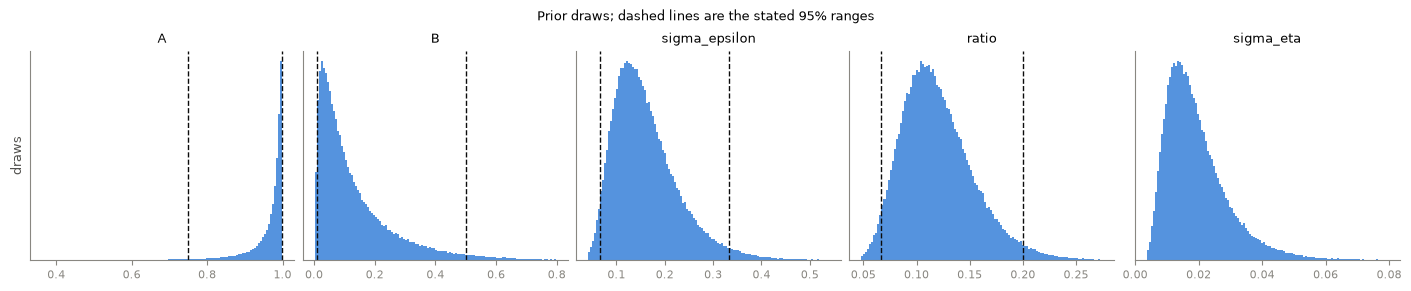

In [6]:
# [prior-histograms] What the prior looks like on the natural scale
fig, axes = plt.subplots(1, 5, figsize=(14, 2.8))
for ax, (name, x) in zip(axes, drawn.items()):
    ax.hist(x, bins=120, range=tuple(np.quantile(x, [0.001, 0.999])), color=BLUE, alpha=0.8)
    for edge in stated.get(name, ()):
        ax.axvline(edge, color="#0b0b0b", lw=1, ls="--")
    ax.set_title(name)
    ax.set_yticks([])
axes[0].set_ylabel("draws")
fig.suptitle("Prior draws; dashed lines are the stated 95% ranges", fontsize=9)
plt.show()

## [check-2] Check 2: the schedules

Each schedule has 8 to 60 blocks of log-normal length, so a sitting's length is a sum of
random block lengths. Each sitting also draws its own mix of the four kinds of block
(baseline, +1, -1, no vision) from a symmetric Dirichlet with concentration 3: a single
kind's share of the blocks then has a Beta(3, 9) distribution, with median 0.24 and
central 95% interval 0.06 to 0.52. The share of *trials* of each kind, shown below,
varies a little more, because blocks differ in length and the first block is always a
baseline.

In [7]:
# [check-schedules] Sitting lengths and the mix of block kinds
schedules = [sample_schedule(rng_schedule, **SCHEDULE) for _ in range(N_SCHEDULES)]
T = np.array([len(p) for p, _ in schedules])
trial_share = np.array([
    [np.mean((p == BLOCK_P[k]) & (v == BLOCK_V[k])) for k in range(len(BLOCK_KINDS))]
    for p, v in schedules
])
no_vision_trials = np.array([np.sum(v == 0) for _, v in schedules])

summary = pd.DataFrame({
    "trials per sitting": np.quantile(T, [0.025, 0.5, 0.975]),
    "no-vision trials per sitting": np.quantile(no_vision_trials, [0.025, 0.5, 0.975]),
    **{f"share of trials: {kind}": np.quantile(trial_share[:, k], [0.025, 0.5, 0.975]) for k, kind in enumerate(BLOCK_KINDS)},
}, index=["2.5%", "median", "97.5%"]).T
summary.round(3)

,2.5%,median,97.5%
trials per sitting,212.000,828.500,1470.025
no-vision trials per sitting,0.000,168.000,599.025
share of trials: baseline,0.053,0.260,0.618
share of trials: +1,0.000,0.219,0.563
share of trials: -1,0.000,0.226,0.559
share of trials: no vision,0.000,0.226,0.558


In [8]:
# [missing-kinds] How often a sitting has no block of a kind at all
pd.Series({
    **{f"no {kind} block": np.mean(trial_share[:, k] == 0) for k, kind in enumerate(BLOCK_KINDS) if kind != "baseline"},
    "no perturbation block at all": np.mean((trial_share[:, 1] == 0) & (trial_share[:, 2] == 0)),
}, name="fraction of sittings").round(3)

no +1 block                     0.035
no -1 block                     0.034
no no vision block              0.035
no perturbation block at all    0.002
Name: fraction of sittings, dtype: float64

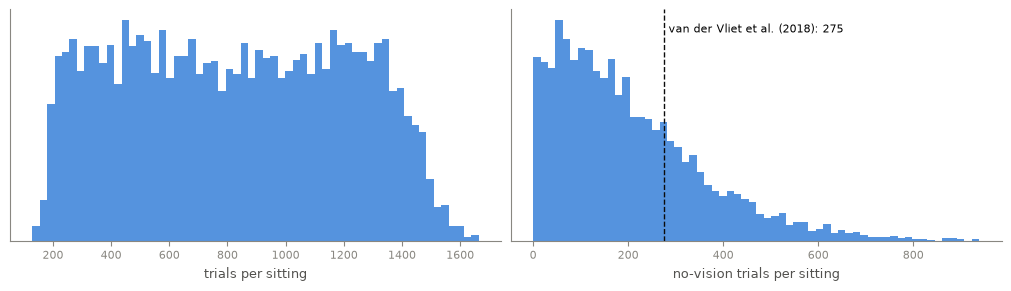

In [9]:
# [schedule-figures] Distribution of sitting length and of no-vision trials
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
axes[0].hist(T, bins=60, color=BLUE, alpha=0.8)
axes[0].set_xlabel("trials per sitting")
axes[1].hist(no_vision_trials, bins=60, color=BLUE, alpha=0.8)
axes[1].axvline(275, color="#0b0b0b", lw=1, ls="--")
axes[1].text(285, axes[1].get_ylim()[1] * 0.9, "van der Vliet et al. (2018): 275", fontsize=8)
axes[1].set_xlabel("no-vision trials per sitting")
for ax in axes:
    ax.set_yticks([])
plt.show()

## [check-3] Check 3: generated sittings

Each panel is one sitting: its own schedule, its own parameters drawn from the prior,
and the movements the simulator produces. Grey bands are no-vision blocks; the grey line
is the perturbation; dots are movements. A learner compensates by moving to $-p$.

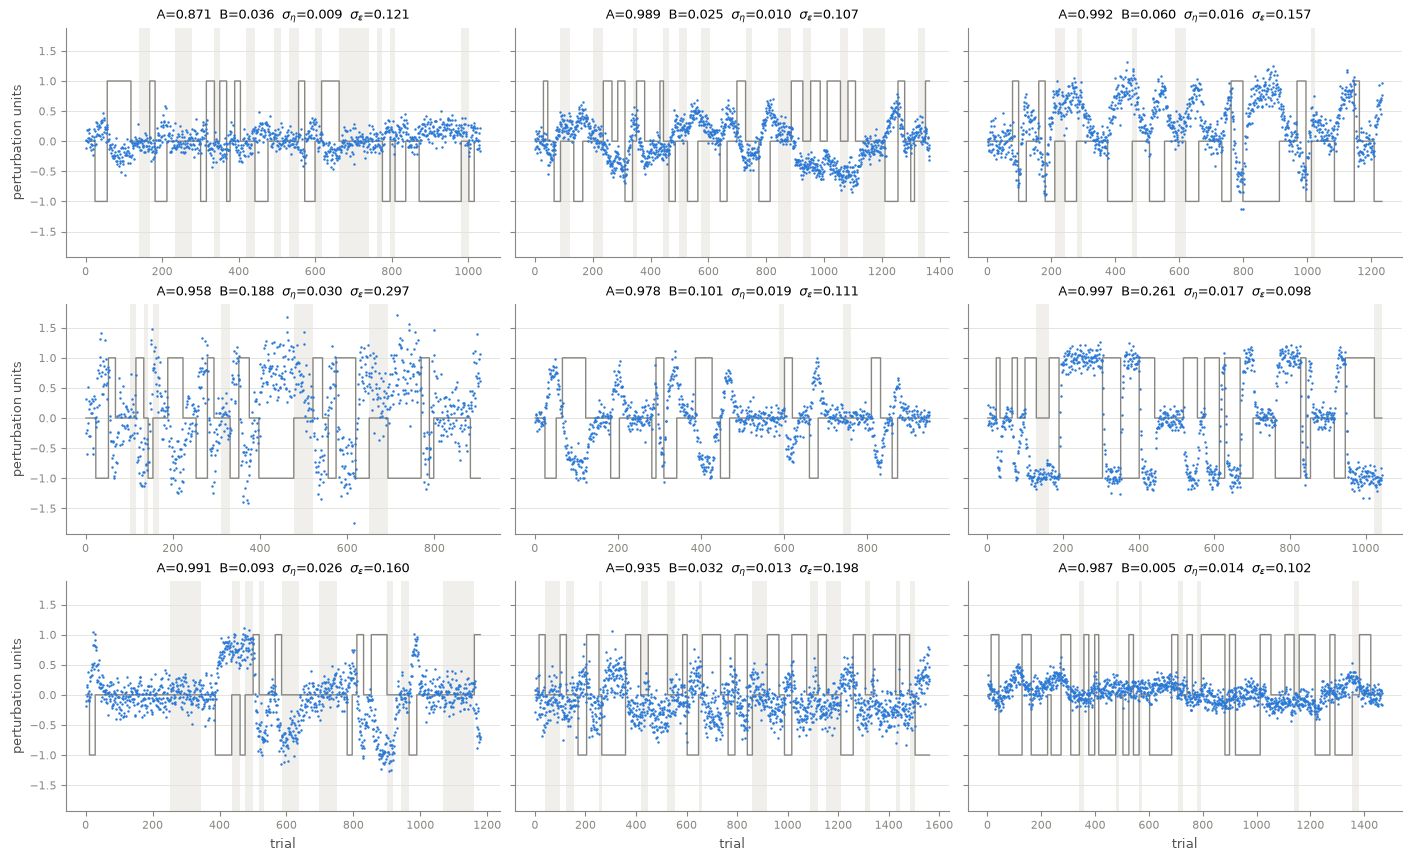

In [10]:
# [generated-sittings] Sittings drawn from the prior and the schedule generator
thetas = sample_prior(rng_example, N_EXAMPLES, **PRIOR)
fig, axes = plt.subplots(3, 3, figsize=(14, 8.5), sharey=True)
for ax, th in zip(axes.flat, thetas):
    p, v = sample_schedule(rng_example, **SCHEDULE)
    y = simulate_sitting(rng_example, th, p, v)
    trial = np.arange(1, len(p) + 1)
    edges = np.nonzero(np.diff(np.r_[1, v, 1]) != 0)[0].reshape(-1, 2)
    for start, stop in edges:
        ax.axvspan(start + 0.5, stop + 0.5, color=SHADE, lw=0)
    ax.step(trial, p, where="mid", color=MUTED, lw=1)
    ax.plot(trial, y, ".", color=BLUE, ms=1.5)
    ax.set_title("A={:.3f}  B={:.3f}  $\\sigma_\\eta$={:.3f}  $\\sigma_\\varepsilon$={:.3f}".format(*th))
    ax.grid(axis="y", color=GRID, lw=0.6)
for ax in axes[-1]:
    ax.set_xlabel("trial")
for ax in axes[:, 0]:
    ax.set_ylabel("perturbation units")
plt.show()

## [results] What this shows

1. **Prior: pass.** Over 200,000 draws, the 2.5% and 97.5% quantiles and the median of
   $A$, $B$, $\sigma_\varepsilon$ and $\sigma_\eta/\sigma_\varepsilon$ match the
   decision's table within sampling error (`[check-prior-ranges]`). The implied
   $\sigma_\eta$ has median 0.017 and central 95% interval 0.0065 to 0.045.
2. **Schedules: as intended.** Sittings have 212 to 1,470 trials (central 95%), median
   about 830 (`[check-schedules]`). Each kind of block takes a median of about a quarter of
   the trials, with wide variation between sittings.
3. **Generated sittings:** for Opher to judge (`[generated-sittings]`).

**Worth deciding on.** Because every block's kind is drawn independently, some sittings
lack a kind altogether (`[missing-kinds]`): about 3.5% have no no-vision block, about
3.5% have no +1 block, about 3.5% no -1 block, and 0.2% no perturbation at all. In those
sittings the data carry
less information about the noises or the adaptation rate, and the network will have to
learn that. Whether that is a feature (realistic variety) or a problem is a question for
Opher. Blocks are also short (median 22 trials) and change often, which is unlike most
real experiments, where adaptation blocks last 100 trials or more.